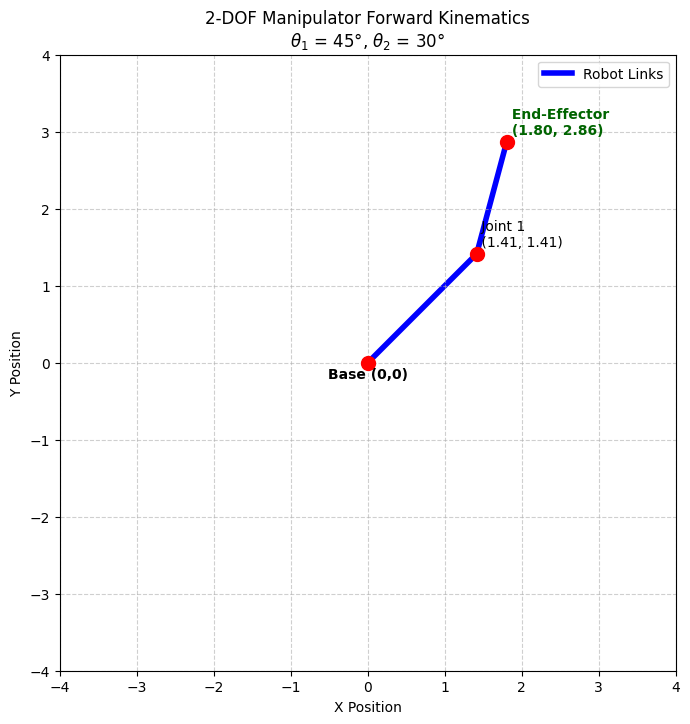

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def forward_kinematics(l1, l2, theta1, theta2):
    """
    Calculate the positions of a 2-DOF planar arm joints.
    Angles should be provided in radians.
    """
    # Coordinates of the first joint (elbow)
    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    # Coordinates of the end-effector
    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    return (x1, y1), (x2, y2)

# ---- Configuration Parameters ----
# Link lengths
L1 = 2.0
L2 = 1.5

# Joint angles (convert degrees to radians)
theta1_deg = 45
theta2_deg = 30

theta1 = np.radians(theta1_deg)
theta2 = np.radians(theta2_deg)

# ---- Run Kinematics ----
joint1, end_effector = forward_kinematics(L1, L2, theta1, theta2)

# Extract coordinates for plotting
x_coords = [0, joint1[0], end_effector[0]]
y_coords = [0, joint1[1], end_effector[1]]

# ---- Plotting ----
plt.figure(figsize=(8, 8))
plt.grid(True, linestyle='--', alpha=0.6)

# Plot the links and joints
plt.plot(x_coords, y_coords, color='blue', linewidth=4, label='Robot Links', zorder=1)
plt.scatter(x_coords, y_coords, color='red', s=100, zorder=2) # Base, Joint 1, End-Effector

# Annotate points
plt.text(0, -0.2, 'Base (0,0)', fontsize=10, ha='center', weight='bold')
plt.text(joint1[0], joint1[1] + 0.1, f' Joint 1\n ({joint1[0]:.2f}, {joint1[1]:.2f})', fontsize=10)
plt.text(end_effector[0], end_effector[1] + 0.1, f' End-Effector\n ({end_effector[0]:.2f}, {end_effector[1]:.2f})', fontsize=10, color='darkgreen', weight='bold')

# Layout limitations to keep a 1:1 scale visual
max_reach = L1 + L2
plt.xlim(-max_reach - 0.5, max_reach + 0.5)
plt.ylim(-max_reach - 0.5, max_reach + 0.5)
plt.gca().set_aspect('equal', adjustable='box')

plt.title(f'2-DOF Manipulator Forward Kinematics\n$\\theta_1$ = {theta1_deg}°, $\\theta_2$ = {theta2_deg}°', fontsize=12)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()

plt.show()

## 6-DOF Manipulator: HEAL 6-DOF Manipulator (Conceptual Model)

This section demonstrates a conceptual forward kinematics model for a 6-DOF arm, similar to a HEAL. Due to the complexity of industrial robots, this is a simplified model for illustration purposes, focusing on the chaining of transformations in 3D space rather than exact Denavit-Hartenberg parameters.


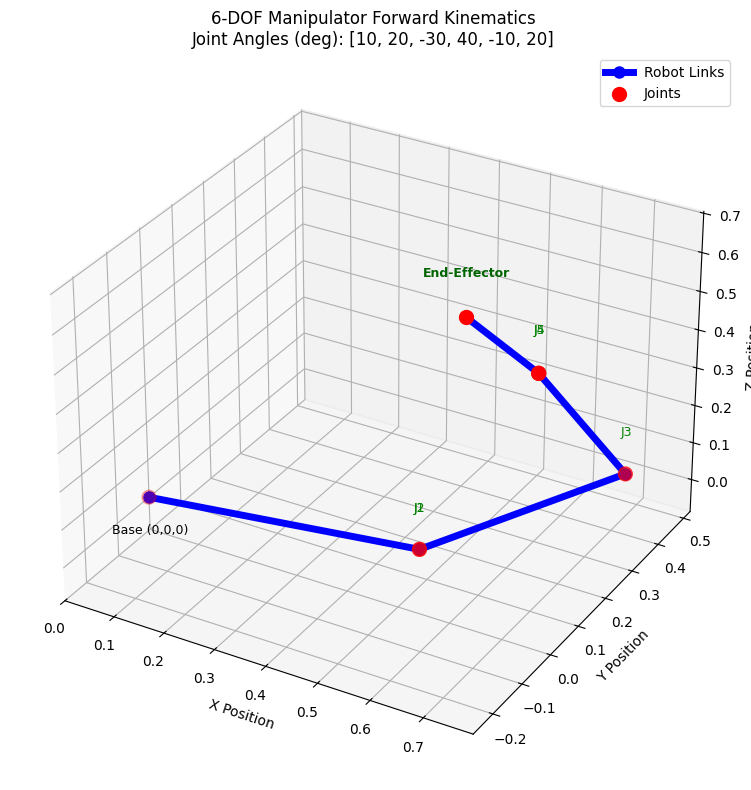

In [18]:
from mpl_toolkits.mplot3d import Axes3D

def create_transformation_matrix(alpha, a, d, theta):
    """
    Generates a Denavit-Hartenberg (DH) transformation matrix.
    This is a conceptual helper for illustration; actual DH tables are specific to robots.
    """
    # Simplified DH parameters for demonstration
    sa = np.sin(alpha)
    ca = np.cos(alpha)
    st = np.sin(theta)
    ct = np.cos(theta)

    T = np.array([
        [ct, -st * ca, st * sa, a * ct],
        [st, ct * ca, -ct * sa, a * st],
        [0, sa, ca, d],
        [0, 0, 0, 1]
    ])
    return T

def forward_kinematics_6dof(angles_rad, link_lengths):
    """
    Conceptual forward kinematics for a 6-DOF arm using simplified transformations.
    `angles_rad` is a list/array of 6 joint angles in radians.
    `link_lengths` is a list/array of conceptual link lengths/offsets.
    """
    # For simplicity, we assume generic rotations around axes and translations.
    # In a real robot, DH parameters define these precisely.
    # Here, 'link_lengths' are used conceptually for 'a' and 'd' parameters.

    num_joints = 6
    if len(angles_rad) != num_joints or len(link_lengths) < num_joints:
        raise ValueError(f"Expected {num_joints} joint angles and at least {num_joints} link lengths.")

    joint_positions = [np.array([0, 0, 0, 1])]
    current_transform = np.eye(4)

    # Example conceptual DH-like parameters. These would be actual values for a real robot.
    # alpha, a, d, theta (theta is the joint angle)
    # We'll use link_lengths for 'a' and 'd' conceptually.
    dh_params_concept = [
        [0, link_lengths[0], 0, angles_rad[0]],  # Base rotation
        [-np.pi/2, 0, 0, angles_rad[1]],         # Shoulder
        [np.pi/2, link_lengths[1], 0, angles_rad[2]], # Elbow
        [-np.pi/2, 0, link_lengths[2], angles_rad[3]], # Wrist 1
        [np.pi/2, 0, 0, angles_rad[4]],          # Wrist 2
        [0, 0, link_lengths[3], angles_rad[5]]   # Wrist 3 (end-effector)
    ]

    for i in range(num_joints):
        alpha, a, d, theta = dh_params_concept[i]
        T_i = create_transformation_matrix(alpha, a, d, theta)
        current_transform = np.dot(current_transform, T_i)
        joint_positions.append(current_transform @ np.array([0, 0, 0, 1]))

    return np.array([pos[:3] for pos in joint_positions])

# ---- Configuration Parameters for 6-DOF ----
L_6dof = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05] # Conceptual link lengths/offsets (extended to 6 elements)

# Joint angles (example: degrees converted to radians)
theta_6dof_deg = [10, 20, -30, 40, -10, 20]
theta_6dof = np.radians(theta_6dof_deg)

# ---- Run Kinematics ----
joint_coords_6dof = forward_kinematics_6dof(theta_6dof, L_6dof)

# ---- Plotting 6-DOF ----
fig_6dof = plt.figure(figsize=(10, 8))
ax_6dof = fig_6dof.add_subplot(111, projection='3d')

# Plot the links
ax_6dof.plot(joint_coords_6dof[:, 0], joint_coords_6dof[:, 1], joint_coords_6dof[:, 2],
             color='blue', linewidth=5, marker='o', markersize=8, label='Robot Links')

# Plot joints (including base and end-effector)
ax_6dof.scatter(joint_coords_6dof[:, 0], joint_coords_6dof[:, 1], joint_coords_6dof[:, 2],
                color='red', s=100, label='Joints')

# Annotate points
ax_6dof.text(joint_coords_6dof[0, 0], joint_coords_6dof[0, 1], joint_coords_6dof[0, 2] - 0.1, 'Base (0,0,0)', color='black', fontsize=9, ha='center')
for i in range(1, len(joint_coords_6dof) - 1):
    ax_6dof.text(joint_coords_6dof[i, 0], joint_coords_6dof[i, 1], joint_coords_6dof[i, 2] + 0.1, f'J{i}', color='green', fontsize=9, ha='center')
ax_6dof.text(joint_coords_6dof[-1, 0], joint_coords_6dof[-1, 1], joint_coords_6dof[-1, 2] + 0.1, 'End-Effector', color='darkgreen', fontsize=9, ha='center', weight='bold')

ax_6dof.set_xlabel('X Position')
ax_6dof.set_ylabel('Y Position')
ax_6dof.set_zlabel('Z Position')
ax_6dof.set_title(f'6-DOF Manipulator (HEAL) Forward Kinematics\nJoint Angles (deg): {theta_6dof_deg}', fontsize=12)
ax_6dof.legend()
ax_6dof.grid(True)

# Set limits and aspect ratio for better visualization
max_range = np.array([joint_coords_6dof[:,0].max()-joint_coords_6dof[:,0].min(),
                      joint_coords_6dof[:,1].max()-joint_coords_6dof[:,1].min(),
                      joint_coords_6dof[:,2].max()-joint_coords_6dof[:,2].min()]).max() / 2.0

mid_x = (joint_coords_6dof[:,0].max()+joint_coords_6dof[:,0].min()) * 0.5
mid_y = (joint_coords_6dof[:,1].max()+joint_coords_6dof[:,1].min()) * 0.5
mid_z = (joint_coords_6dof[:,2].max()+joint_coords_6dof[:,2].min()) * 0.5

ax_6dof.set_xlim(mid_x - max_range, mid_x + max_range)
ax_6dof.set_ylim(mid_y - max_range, mid_y + max_range)
ax_6dof.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()


## 7-DOF Manipulator: FRANKA 7-DOF Manipulator (Conceptual Model)

This section provides a conceptual forward kinematics model for a 7-DOF arm, such as the FRANKA. As with the 6-DOF model, this is a simplified representation to illustrate the principles of multi-joint kinematics and 3D visualization, rather than an exact kinematic replica of the specific robot.


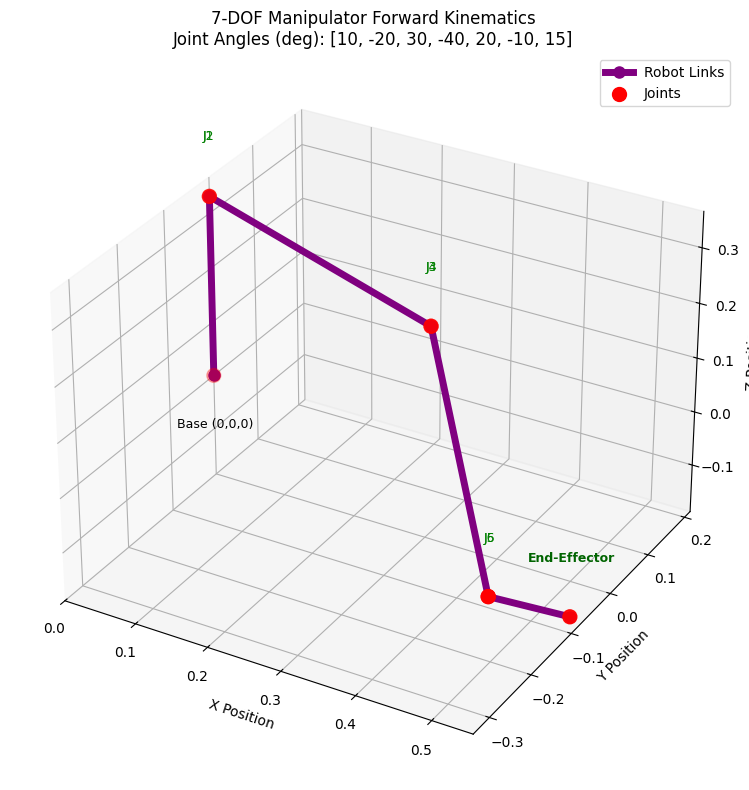

In [19]:
def forward_kinematics_7dof(angles_rad, link_lengths):
    """
    Conceptual forward kinematics for a 7-DOF arm using simplified transformations.
    `angles_rad` is a list/array of 7 joint angles in radians.
    `link_lengths` is a list/array of conceptual link lengths/offsets.
    """
    num_joints = 7
    if len(angles_rad) != num_joints or len(link_lengths) < num_joints:
        raise ValueError(f"Expected {num_joints} joint angles and at least {num_joints} link lengths.")

    joint_positions = [np.array([0, 0, 0, 1])]
    current_transform = np.eye(4)

    # Example conceptual DH-like parameters for a 7-DOF arm.
    # These are illustrative and not the actual DH parameters for FRANKA.
    # alpha, a, d, theta (theta is the joint angle)
    dh_params_concept = [
        [0, 0, link_lengths[0], angles_rad[0]],  # J1
        [-np.pi/2, 0, 0, angles_rad[1]],         # J2
        [np.pi/2, link_lengths[1], link_lengths[2], angles_rad[2]], # J3
        [-np.pi/2, 0, 0, angles_rad[3]],         # J4
        [np.pi/2, link_lengths[3], link_lengths[4], angles_rad[4]], # J5
        [-np.pi/2, 0, 0, angles_rad[5]],         # J6
        [np.pi/2, 0, link_lengths[5], angles_rad[6]]   # J7 (end-effector)
    ]

    for i in range(num_joints):
        alpha, a, d, theta = dh_params_concept[i]
        T_i = create_transformation_matrix(alpha, a, d, theta) # Reusing helper function
        current_transform = np.dot(current_transform, T_i)
        joint_positions.append(current_transform @ np.array([0, 0, 0, 1]))

    return np.array([pos[:3] for pos in joint_positions])

# ---- Configuration Parameters for 7-DOF ----
L_7dof = [0.33, 0.316, 0.088, 0.384, 0.088, 0.107, 0.05] # Conceptual link lengths/offsets for FRANKA-like arm (extended to 7 elements)

# Joint angles (example: degrees converted to radians)
theta_7dof_deg = [10, -20, 30, -40, 20, -10, 15]
theta_7dof = np.radians(theta_7dof_deg)

# ---- Run Kinematics ----
joint_coords_7dof = forward_kinematics_7dof(theta_7dof, L_7dof)

# ---- Plotting 7-DOF ----
fig_7dof = plt.figure(figsize=(10, 8))
ax_7dof = fig_7dof.add_subplot(111, projection='3d')

# Plot the links
ax_7dof.plot(joint_coords_7dof[:, 0], joint_coords_7dof[:, 1], joint_coords_7dof[:, 2],
             color='purple', linewidth=5, marker='o', markersize=8, label='Robot Links')

# Plot joints (including base and end-effector)
ax_7dof.scatter(joint_coords_7dof[:, 0], joint_coords_7dof[:, 1], joint_coords_7dof[:, 2],
                color='red', s=100, label='Joints')

# Annotate points
ax_7dof.text(joint_coords_7dof[0, 0], joint_coords_7dof[0, 1], joint_coords_7dof[0, 2] - 0.1, 'Base (0,0,0)', color='black', fontsize=9, ha='center')
for i in range(1, len(joint_coords_7dof) - 1):
    ax_7dof.text(joint_coords_7dof[i, 0], joint_coords_7dof[i, 1], joint_coords_7dof[i, 2] + 0.1, f'J{i}', color='green', fontsize=9, ha='center')
ax_7dof.text(joint_coords_7dof[-1, 0], joint_coords_7dof[-1, 1], joint_coords_7dof[-1, 2] + 0.1, 'End-Effector', color='darkgreen', fontsize=9, ha='center', weight='bold')

ax_7dof.set_xlabel('X Position')
ax_7dof.set_ylabel('Y Position')
ax_7dof.set_zlabel('Z Position')
ax_7dof.set_title(f'7-DOF Manipulator (FRANKA) Forward Kinematics\nJoint Angles (deg): {theta_7dof_deg}', fontsize=12)
ax_7dof.legend()
ax_7dof.grid(True)

# Set limits and aspect ratio for better visualization
max_range = np.array([joint_coords_7dof[:,0].max()-joint_coords_7dof[:,0].min(),
                      joint_coords_7dof[:,1].max()-joint_coords_7dof[:,1].min(),
                      joint_coords_7dof[:,2].max()-joint_coords_7dof[:,2].min()]).max() / 2.0

mid_x = (joint_coords_7dof[:,0].max()+joint_coords_7dof[:,0].min()) * 0.5
mid_y = (joint_coords_7dof[:,1].max()+joint_coords_7dof[:,1].min()) * 0.5
mid_z = (joint_coords_7dof[:,2].max()+joint_coords_7dof[:,2].min()) * 0.5

ax_7dof.set_xlim(mid_x - max_range, mid_x + max_range)
ax_7dof.set_ylim(mid_y - max_range, mid_y + max_range)
ax_7dof.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()


## Animation: 6-DOF Manipulator Movement

This section animates the 6-DOF conceptual manipulator by varying one of its joint angles (the base rotation, `theta_6dof[0]`) over a defined range. The animation will show how the robot's end-effector moves in 3D space as this joint rotates.

In [20]:
import matplotlib.animation as animation
from IPython.display import HTML

# Reusing existing functions: forward_kinematics_6dof, create_transformation_matrix
# Reusing existing parameters: L_6dof, theta_6dof

# Setup the figure and axes for the animation
fig_anim = plt.figure(figsize=(10, 8))
ax_anim = fig_anim.add_subplot(111, projection='3d')

# Initialize the plot for the animation
line, = ax_anim.plot([], [], [], 'b-o', lw=5, markersize=8, label='Robot Links')
points = ax_anim.scatter([], [], [], 'r', s=100, label='Joints')

# Set static plot limits for consistency during animation
# Based on the maximum reach, or a reasonable fixed range
max_arm_reach = sum(L_6dof) # Sum of conceptual link lengths
ax_anim.set_xlim([-max_arm_reach - 0.5, max_arm_reach + 0.5])
ax_anim.set_ylim([-max_arm_reach - 0.5, max_arm_reach + 0.5])
ax_anim.set_zlim([-max_arm_reach - 0.5, max_arm_reach + 0.5])

ax_anim.set_xlabel('X Position')
ax_anim.set_ylabel('Y Position')
ax_anim.set_zlabel('Z Position')
ax_anim.set_title('6-DOF Manipulator (HEAL) Animation')
ax_anim.legend()
ax_anim.grid(True)

# Function to initialize the animation
def init():
    line.set_data([], [])
    line.set_3d_properties([])
    points._offsets3d = ([],[],[]) # Clear previous scatter points
    return line, points

# Function to update the plot for each frame of the animation
def animate(i):
    # Vary the first joint angle (base rotation) from -90 to 90 degrees
    angle_range_deg = np.linspace(-90, 90, 100) # 100 frames
    current_base_angle = np.radians(angle_range_deg[i])

    # Update the first angle in the theta_6dof array
    current_theta_6dof = list(theta_6dof) # Convert to list to modify
    current_theta_6dof[0] = current_base_angle

    # Recalculate forward kinematics
    joint_coords = forward_kinematics_6dof(current_theta_6dof, L_6dof)

    # Update line data
    line.set_data(joint_coords[:, 0], joint_coords[:, 1])
    line.set_3d_properties(joint_coords[:, 2])

    # Update scatter data for joints
    points._offsets3d = (joint_coords[:, 0], joint_coords[:, 1], joint_coords[:, 2])

    ax_anim.set_title(f'6-DOF Manipulator (HEAL) Animation\nBase Angle: {np.degrees(current_base_angle):.1f}°')

    return line, points

# Create the animation
# `blit=True` might cause issues with 3D plots, setting to False
ani = animation.FuncAnimation(fig_anim, animate, frames=100, init_func=init, blit=False, interval=50)

# Save the animation as an HTML5 video and display it
# Requires FFmpeg to be installed, which is usually available in Colab environments.
# You might need to install 'ffmpeg-python' if it's not present: !pip install ffmpeg-python
video = ani.to_html5_video()

# Close the plot to prevent it from displaying as a static image
plt.close(fig_anim)

HTML(video)


## Refactored Code: Modular Structure

### 1. Essential Imports

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import HTML

### 2. Core Kinematics Functions

In [22]:
def forward_kinematics_2dof(l1, l2, theta1, theta2):
    """
    Calculate the positions of a 2-DOF planar arm joints.
    Angles should be provided in radians.
    """
    # Coordinates of the first joint (elbow)
    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    # Coordinates of the end-effector
    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    return (x1, y1), (x2, y2)

def create_transformation_matrix(alpha, a, d, theta):
    """
    Generates a Denavit-Hartenberg (DH) transformation matrix.
    The DH parameters (alpha, a, d, theta) define the geometric relationship
    between two consecutive links.
    """
    sa = np.sin(alpha)
    ca = np.cos(alpha)
    st = np.sin(theta)
    ct = np.cos(theta)

    T = np.array([
        [ct, -st * ca, st * sa, a * ct],
        [st, ct * ca, -ct * sa, a * st],
        [0, sa, ca, d],
        [0, 0, 0, 1]
    ])
    return T

def forward_kinematics_dh(joint_angles, dh_table):
    """
    Calculates forward kinematics for a multi-DOF arm using Denavit-Hartenberg parameters.
    This function is generalized to accept different numbers of joints and DH tables.

    `joint_angles` is a list/array of joint angles in radians (e.g., [q1, q2, ..., qN]).
    `dh_table` is a list of lists/tuples, where each inner element represents
    [alpha, a, d, theta_offset] for a link. The `theta_offset` is a fixed angle
    component for the joint as defined in the standard DH convention.
    The actual joint angle used in the transformation for link `i` is `joint_angles[i] + dh_table[i][3]`.
    """
    num_joints = len(joint_angles)
    if num_joints != len(dh_table):
        raise ValueError("Number of joint angles must match the number of entries in the DH table.")

    joint_positions = [np.array([0, 0, 0, 1])]
    current_transform = np.eye(4)

    for i in range(num_joints):
        alpha, a, d, theta_fixed_offset = dh_table[i]
        # The total theta for the transformation is the variable joint angle plus its fixed offset
        theta_total = joint_angles[i] + theta_fixed_offset
        T_i = create_transformation_matrix(alpha, a, d, theta_total)
        current_transform = np.dot(current_transform, T_i)
        # The position of the origin of the next coordinate frame (end of current link)
        joint_positions.append(current_transform @ np.array([0, 0, 0, 1]))

    return np.array([pos[:3] for pos in joint_positions])

### 3. 2-DOF Planar Arm: Configuration and Plotting

In [23]:
# ---- Configuration Parameters for 2-DOF ----
L1_2dof = 2.0
L2_2dof = 1.5

theta1_2dof_deg = 45
theta2_2dof_deg = 30

theta1_2dof_rad = np.radians(theta1_2dof_deg)
theta2_2dof_rad = np.radians(theta2_2dof_deg)

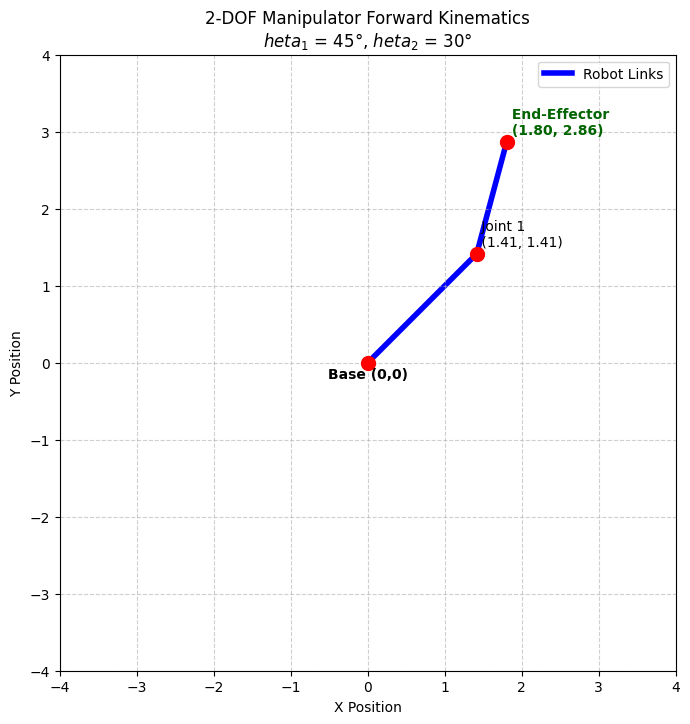

In [24]:
# ---- Run 2-DOF Kinematics ----
joint1_2dof, end_effector_2dof = forward_kinematics_2dof(L1_2dof, L2_2dof, theta1_2dof_rad, theta2_2dof_rad)

# Extract coordinates for plotting
x_coords_2dof = [0, joint1_2dof[0], end_effector_2dof[0]]
y_coords_2dof = [0, joint1_2dof[1], end_effector_2dof[1]]

# ---- Plotting 2-DOF ----
plt.figure(figsize=(8, 8))
plt.grid(True, linestyle='--', alpha=0.6)

# Plot the links and joints
plt.plot(x_coords_2dof, y_coords_2dof, color='blue', linewidth=4, label='Robot Links', zorder=1)
plt.scatter(x_coords_2dof, y_coords_2dof, color='red', s=100, zorder=2) # Base, Joint 1, End-Effector

# Annotate points
plt.text(0, -0.2, 'Base (0,0)', fontsize=10, ha='center', weight='bold')
plt.text(joint1_2dof[0], joint1_2dof[1] + 0.1, f' Joint 1\n ({joint1_2dof[0]:.2f}, {joint1_2dof[1]:.2f})', fontsize=10)
plt.text(end_effector_2dof[0], end_effector_2dof[1] + 0.1, f' End-Effector\n ({end_effector_2dof[0]:.2f}, {end_effector_2dof[1]:.2f})', fontsize=10, color='darkgreen', weight='bold')

# Layout limitations to keep a 1:1 scale visual
max_reach_2dof = L1_2dof + L2_2dof
plt.xlim(-max_reach_2dof - 0.5, max_reach_2dof + 0.5)
plt.ylim(-max_reach_2dof - 0.5, max_reach_2dof + 0.5)
plt.gca().set_aspect('equal', adjustable='box')

plt.title(f'2-DOF Manipulator Forward Kinematics\n$\theta_1$ = {theta1_2dof_deg}°, $\theta_2$ = {theta2_2dof_deg}°', fontsize=12)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()

plt.show()

### 4. 6-DOF Manipulator: Configuration and Plotting

In [25]:
# ---- Configuration Parameters for 6-DOF ----
L_6dof_config = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05] # Conceptual link lengths/offsets

# Joint angles (example: degrees converted to radians)
theta_6dof_deg_config = [10, 20, -30, 40, -10, 20]
theta_6dof_rad_config = np.radians(theta_6dof_deg_config)

# Conceptual DH table for a 6-DOF arm. `theta_offset` is 0 here as the variable angle is directly applied.
# [alpha, a, d, theta_fixed_offset]
dh_table_6dof = [
    [0, L_6dof_config[0], 0, 0],       # Base rotation (link_lengths[0] for 'a')
    [-np.pi/2, 0, 0, 0],                # Shoulder
    [np.pi/2, L_6dof_config[1], 0, 0],  # Elbow (link_lengths[1] for 'a')
    [-np.pi/2, 0, L_6dof_config[2], 0], # Wrist 1 (link_lengths[2] for 'd')
    [np.pi/2, 0, 0, 0],                 # Wrist 2
    [0, 0, L_6dof_config[3], 0]         # Wrist 3 (end-effector) (link_lengths[3] for 'd')
]

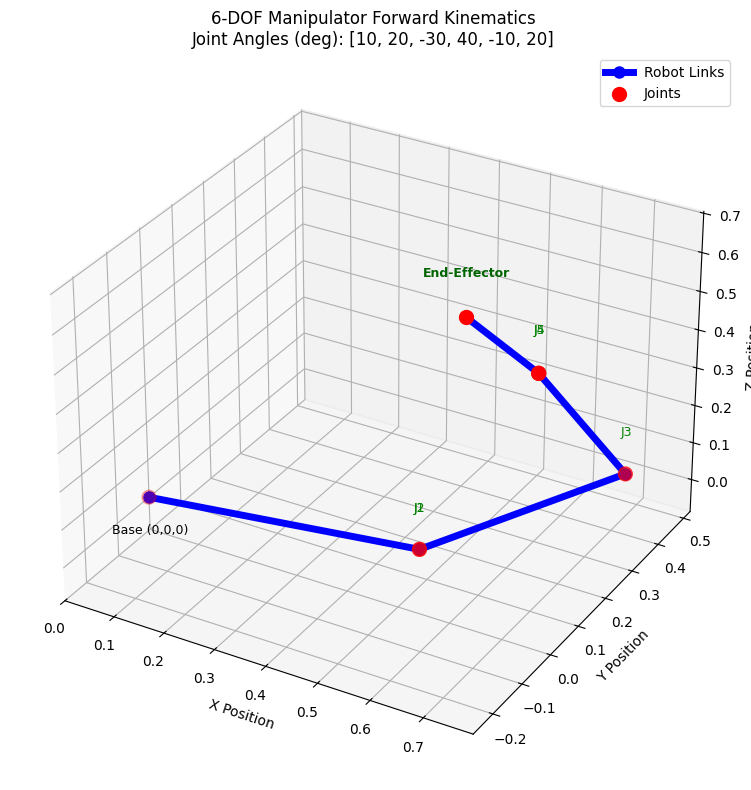

In [26]:
# ---- Run 6-DOF Kinematics (using generalized DH function) ----
joint_coords_6dof_refactored = forward_kinematics_dh(theta_6dof_rad_config, dh_table_6dof)

# ---- Plotting 6-DOF ----
fig_6dof_refactored = plt.figure(figsize=(10, 8))
ax_6dof_refactored = fig_6dof_refactored.add_subplot(111, projection='3d')

# Plot the links
ax_6dof_refactored.plot(joint_coords_6dof_refactored[:, 0], joint_coords_6dof_refactored[:, 1], joint_coords_6dof_refactored[:, 2],
             color='blue', linewidth=5, marker='o', markersize=8, label='Robot Links')

# Plot joints (including base and end-effector)
ax_6dof_refactored.scatter(joint_coords_6dof_refactored[:, 0], joint_coords_6dof_refactored[:, 1], joint_coords_6dof_refactored[:, 2],
                color='red', s=100, label='Joints')

# Annotate points
ax_6dof_refactored.text(joint_coords_6dof_refactored[0, 0], joint_coords_6dof_refactored[0, 1], joint_coords_6dof_refactored[0, 2] - 0.1, 'Base (0,0,0)', color='black', fontsize=9, ha='center')
for i in range(1, len(joint_coords_6dof_refactored) - 1):
    ax_6dof_refactored.text(joint_coords_6dof_refactored[i, 0], joint_coords_6dof_refactored[i, 1], joint_coords_6dof_refactored[i, 2] + 0.1, f'J{i}', color='green', fontsize=9, ha='center')
ax_6dof_refactored.text(joint_coords_6dof_refactored[-1, 0], joint_coords_6dof_refactored[-1, 1], joint_coords_6dof_refactored[-1, 2] + 0.1, 'End-Effector', color='darkgreen', fontsize=9, ha='center', weight='bold')

ax_6dof_refactored.set_xlabel('X Position')
ax_6dof_refactored.set_ylabel('Y Position')
ax_6dof_refactored.set_zlabel('Z Position')
ax_6dof_refactored.set_title(f'6-DOF Manipulator (HEAL) Forward Kinematics\nJoint Angles (deg): {theta_6dof_deg_config}', fontsize=12)
ax_6dof_refactored.legend()
ax_6dof_refactored.grid(True)

# Set limits and aspect ratio for better visualization
max_range_6dof = np.array([joint_coords_6dof_refactored[:,0].max()-joint_coords_6dof_refactored[:,0].min(),
                            joint_coords_6dof_refactored[:,1].max()-joint_coords_6dof_refactored[:,1].min(),
                            joint_coords_6dof_refactored[:,2].max()-joint_coords_6dof_refactored[:,2].min()]).max() / 2.0

mid_x_6dof = (joint_coords_6dof_refactored[:,0].max()+joint_coords_6dof_refactored[:,0].min()) * 0.5
mid_y_6dof = (joint_coords_6dof_refactored[:,1].max()+joint_coords_6dof_refactored[:,1].min()) * 0.5
mid_z_6dof = (joint_coords_6dof_refactored[:,2].max()+joint_coords_6dof_refactored[:,2].min()) * 0.5

ax_6dof_refactored.set_xlim(mid_x_6dof - max_range_6dof, mid_x_6dof + max_range_6dof)
ax_6dof_refactored.set_ylim(mid_y_6dof - max_range_6dof, mid_y_6dof + max_range_6dof)
ax_6dof_refactored.set_zlim(mid_z_6dof - max_range_6dof, mid_z_6dof + max_range_6dof)

plt.tight_layout()
plt.show()

### 5. 7-DOF Manipulator: Configuration and Plotting

In [27]:
# ---- Configuration Parameters for 7-DOF ----
L_7dof_config = [0.33, 0.316, 0.088, 0.384, 0.088, 0.107, 0.05] # Conceptual link lengths/offsets for FRANKA-like arm

# Joint angles (example: degrees converted to radians)
theta_7dof_deg_config = [10, -20, 30, -40, 20, -10, 15]
theta_7dof_rad_config = np.radians(theta_7dof_deg_config)

# Conceptual DH table for a 7-DOF arm. `theta_offset` is 0 here as the variable angle is directly applied.
# [alpha, a, d, theta_fixed_offset]
dh_table_7dof = [
    [0, 0, L_7dof_config[0], 0],      # J1
    [-np.pi/2, 0, 0, 0],               # J2
    [np.pi/2, L_7dof_config[1], L_7dof_config[2], 0], # J3
    [-np.pi/2, 0, 0, 0],               # J4
    [np.pi/2, L_7dof_config[3], L_7dof_config[4], 0], # J5
    [-np.pi/2, 0, 0, 0],               # J6
    [np.pi/2, 0, L_7dof_config[5], 0]  # J7 (end-effector)
]

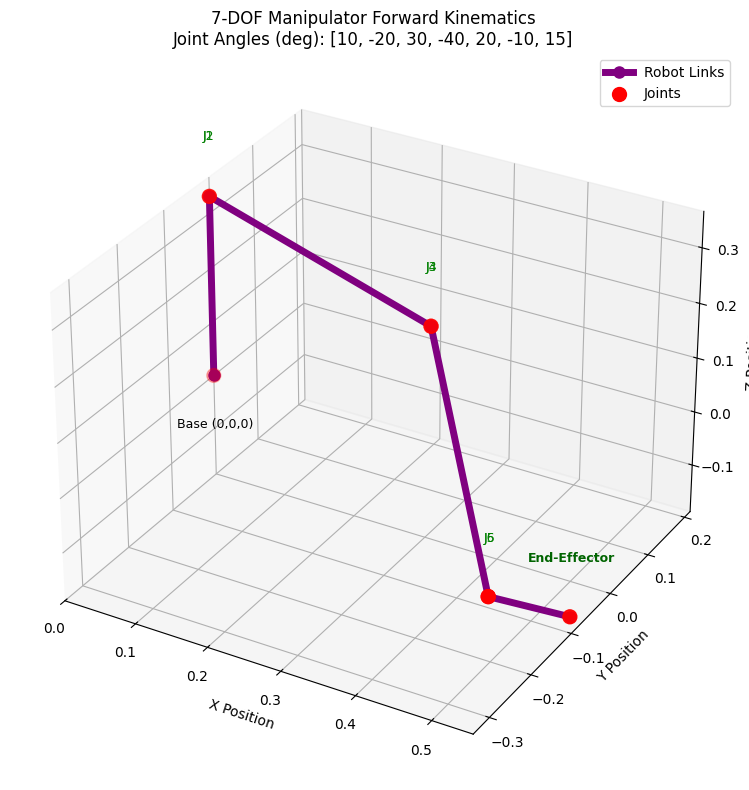

In [28]:
# ---- Run 7-DOF Kinematics (using generalized DH function) ----
joint_coords_7dof_refactored = forward_kinematics_dh(theta_7dof_rad_config, dh_table_7dof)

# ---- Plotting 7-DOF ----
fig_7dof_refactored = plt.figure(figsize=(10, 8))
ax_7dof_refactored = fig_7dof_refactored.add_subplot(111, projection='3d')

# Plot the links
ax_7dof_refactored.plot(joint_coords_7dof_refactored[:, 0], joint_coords_7dof_refactored[:, 1], joint_coords_7dof_refactored[:, 2],
             color='purple', linewidth=5, marker='o', markersize=8, label='Robot Links')

# Plot joints (including base and end-effector)
ax_7dof_refactored.scatter(joint_coords_7dof_refactored[:, 0], joint_coords_7dof_refactored[:, 1], joint_coords_7dof_refactored[:, 2],
                color='red', s=100, label='Joints')

# Annotate points
ax_7dof_refactored.text(joint_coords_7dof_refactored[0, 0], joint_coords_7dof_refactored[0, 1], joint_coords_7dof_refactored[0, 2] - 0.1, 'Base (0,0,0)', color='black', fontsize=9, ha='center')
for i in range(1, len(joint_coords_7dof_refactored) - 1):
    ax_7dof_refactored.text(joint_coords_7dof_refactored[i, 0], joint_coords_7dof_refactored[i, 1], joint_coords_7dof_refactored[i, 2] + 0.1, f'J{i}', color='green', fontsize=9, ha='center')
ax_7dof_refactored.text(joint_coords_7dof_refactored[-1, 0], joint_coords_7dof_refactored[-1, 1], joint_coords_7dof_refactored[-1, 2] + 0.1, 'End-Effector', color='darkgreen', fontsize=9, ha='center', weight='bold')

ax_7dof_refactored.set_xlabel('X Position')
ax_7dof_refactored.set_ylabel('Y Position')
ax_7dof_refactored.set_zlabel('Z Position')
ax_7dof_refactored.set_title(f'7-DOF Manipulator (FRANKA) Forward Kinematics\nJoint Angles (deg): {theta_7dof_deg_config}', fontsize=12)
ax_7dof_refactored.legend()
ax_7dof_refactored.grid(True)

# Set limits and aspect ratio for better visualization
max_range_7dof = np.array([joint_coords_7dof_refactored[:,0].max()-joint_coords_7dof_refactored[:,0].min(),
                            joint_coords_7dof_refactored[:,1].max()-joint_coords_7dof_refactored[:,1].min(),
                            joint_coords_7dof_refactored[:,2].max()-joint_coords_7dof_refactored[:,2].min()]).max() / 2.0

mid_x_7dof = (joint_coords_7dof_refactored[:,0].max()+joint_coords_7dof_refactored[:,0].min()) * 0.5
mid_y_7dof = (joint_coords_7dof_refactored[:,1].max()+joint_coords_7dof_refactored[:,1].min()) * 0.5
mid_z_7dof = (joint_coords_7dof_refactored[:,2].max()+joint_coords_7dof_refactored[:,2].min()) * 0.5

ax_7dof_refactored.set_xlim(mid_x_7dof - max_range_7dof, mid_x_7dof + max_range_7dof)
ax_7dof_refactored.set_ylim(mid_y_7dof - max_range_7dof, mid_y_7dof + max_range_7dof)
ax_7dof_refactored.set_zlim(mid_z_7dof - max_range_7dof, mid_z_7dof + max_range_7dof)

plt.tight_layout()
plt.show()

### 6. Animation: 6-DOF Manipulator Movement (Refactored)

In [29]:
# Reusing `forward_kinematics_dh`, `create_transformation_matrix`,
# and the 6-DOF configuration parameters (`L_6dof_config`, `theta_6dof_rad_config`, `dh_table_6dof`)

# Setup the figure and axes for the animation
fig_anim_refactored = plt.figure(figsize=(10, 8))
ax_anim_refactored = fig_anim_refactored.add_subplot(111, projection='3d')

# Initialize the plot for the animation
line_anim, = ax_anim_refactored.plot([], [], [], 'b-o', lw=5, markersize=8, label='Robot Links')
points_anim = ax_anim_refactored.scatter([], [], [], 'r', s=100, label='Joints')

# Set static plot limits for consistency during animation
# Based on the maximum reach of the 6-DOF arm
max_arm_reach_anim = sum(L_6dof_config) # Sum of conceptual link lengths
ax_anim_refactored.set_xlim([-max_arm_reach_anim - 0.5, max_arm_reach_anim + 0.5])
ax_anim_refactored.set_ylim([-max_arm_reach_anim - 0.5, max_arm_reach_anim + 0.5])
ax_anim_refactored.set_zlim([-max_arm_reach_anim - 0.5, max_arm_reach_anim + 0.5])

ax_anim_refactored.set_xlabel('X Position')
ax_anim_refactored.set_ylabel('Y Position')
ax_anim_refactored.set_zlabel('Z Position')
ax_anim_refactored.set_title('6-DOF Manipulator (HEAL) Animation')
ax_anim_refactored.legend()
ax_anim_refactored.grid(True)

# Function to initialize the animation
def init_refactored():
    line_anim.set_data([], [])
    line_anim.set_3d_properties([])
    points_anim._offsets3d = ([],[],[]) # Clear previous scatter points
    return line_anim, points_anim

# Function to update the plot for each frame of the animation
def animate_refactored(i):
    # Vary the first joint angle (base rotation) from -90 to 90 degrees
    angle_range_deg_anim = np.linspace(-90, 90, 100) # 100 frames
    current_base_angle_rad = np.radians(angle_range_deg_anim[i])

    # Create a copy of the current 6-DOF joint angles and modify the first one
    current_theta_6dof_anim = list(theta_6dof_rad_config) # Convert to list to modify
    current_theta_6dof_anim[0] = current_base_angle_rad

    # Recalculate forward kinematics using the generalized DH function
    joint_coords_anim = forward_kinematics_dh(current_theta_6dof_anim, dh_table_6dof)

    # Update line data
    line_anim.set_data(joint_coords_anim[:, 0], joint_coords_anim[:, 1])
    line_anim.set_3d_properties(joint_coords_anim[:, 2])

    # Update scatter data for joints
    points_anim._offsets3d = (joint_coords_anim[:, 0], joint_coords_anim[:, 1], joint_coords_anim[:, 2])

    ax_anim_refactored.set_title(f'6-DOF Manipulator (HEAL) Animation\nBase Angle: {np.degrees(current_base_angle_rad):.1f}°')

    return line_anim, points_anim

# Create the animation
ani_refactored = animation.FuncAnimation(fig_anim_refactored, animate_refactored, frames=100, init_func=init_refactored, blit=False, interval=50)

# Save the animation as an HTML5 video and display it
video_refactored = ani_refactored.to_html5_video()

# Close the plot to prevent it from displaying as a static image
plt.close(fig_anim_refactored)

HTML(video_refactored)